# RL - Chapter 6 - TD - Cliff Walking


In [22]:
from toc import generate_toc

path = 'ch_6_TD_p3_cliff_walking.ipynb'
generate_toc(path)

## Table of Contents

- [RL - Chapter 6 - TD - Cliff Walking](#rl-chapter-6-td-cliff-walking)
  - [Clif Walking environment](#clif-walking-environment)
  - [Sarsa](#sarsa)
  - [result](#result)

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# set decimal precision for numpy arrays
np.set_printoptions(precision=1, suppress=True)


def argmax_random_tie(values: np.ndarray) -> int:
    values = np.asarray(values)
    max_value = np.max(values)
    candidates = np.flatnonzero(values == max_value)
    return int(np.random.choice(candidates))

## Clif Walking environment


In [24]:
# Cliff Walking environment
class CliffWalking:
    def __init__(self):
        self.y_max = 4
        self.x_max = 12
        self.start = (0, 0)
        self.goal = (11, 0)
        self.cliff = [(i, 0) for i in range(1, 11)]
        self.actions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
        self.n_actions = len(self.actions)

In [25]:
# Q-learning agent
class QLearning:
    def __init__(self, env: CliffWalking, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=500, dual_learning=False):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_episodes = n_episodes
        self.dual_learning = dual_learning
        self.Q = defaultdict(lambda: np.zeros(self.env.n_actions))
        self.Q2 = defaultdict(lambda: np.zeros(self.env.n_actions))
        self.sum_rewards = np.zeros(n_episodes)

    def run(self):
        for episode in range(self.n_episodes):
            # print(f'Episode {episode + 1}/{self.n_episodes}', end='\r')
            state = self.env.start
            n_steps = 0
            sum_rewards = 0
            while n_steps < 10000:
                action = self.choose_action(state)
                next_state, reward, done = self.step(state, action)
                if self.dual_learning:
                    self.double_learning_update(state, action, reward, next_state, done)
                else:
                    best_next_action = argmax_random_tie(self.Q[next_state])
                    td_target = reward if done else reward + self.gamma * self.Q[next_state][best_next_action]
                    td_error = td_target - self.Q[state][action]
                    self.Q[state][action] += self.alpha * td_error
                state = next_state
                n_steps += 1
                sum_rewards += reward
                if done:
                    break
            # ensure goal state has zero value
            self.Q[self.env.goal] = np.zeros(self.env.n_actions)
            self.sum_rewards[episode] = sum_rewards

    def double_learning_update(self, state, action, reward, next_state, done):
        if np.random.rand() < 0.5:
            best_next_action = argmax_random_tie(self.Q[next_state])
            td_target = reward if done else reward + self.gamma * self.Q2[next_state][best_next_action]
            td_error = td_target - self.Q[state][action]
            self.Q[state][action] += self.alpha * td_error
        else:
            best_next_action = argmax_random_tie(self.Q2[next_state])
            td_target = reward if done else reward + self.gamma * self.Q[next_state][best_next_action]
            td_error = td_target - self.Q2[state][action]
            self.Q2[state][action] += self.alpha * td_error

    def step(self, state, action):
        '''take action and return next state, reward, and done flag'''
        x, y = state
        dx, dy = self.env.actions[action]
        next_state = (x + dx, y + dy)
        # check for boundaries
        next_state = (max(0, min(self.env.x_max - 1, next_state[0])),
                      max(0, min(self.env.y_max - 1, next_state[1])))
        reward = -1
        done = False
        if next_state in self.env.cliff:
            reward = -100
            next_state = self.env.start
        elif next_state == self.env.goal:
            done = True
            reward = -1
        return next_state, reward, done

    def choose_action(self, state):
        '''epsilon-greedy action selection'''
        if np.random.rand() < self.epsilon:
            return int(np.random.choice(self.env.n_actions))
        return argmax_random_tie(self.Q[state])

## Sarsa


In [26]:
class Sarsa:
    def __init__(self, env: CliffWalking, alpha=0.5, gamma=1.0, epsilon=0.1, n_episodes=500, use_expected_sarsa=False):
        self.env = env
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.n_episodes = n_episodes
        self.use_expected_sarsa = use_expected_sarsa
        self.Q = defaultdict(lambda: np.zeros(self.env.n_actions))
        self.sum_rewards = np.zeros(n_episodes)

    def run(self):
        for episode in range(self.n_episodes):
            # print(f'Episode {episode + 1}/{self.n_episodes}', end='\r')
            state = self.env.start
            action = self.choose_action(state)
            n_steps = 0
            sum_rewards = 0
            while n_steps < 10000:
                next_state, reward, done = self.step(state, action)
                next_action = self.choose_action(next_state)
                # update Q-value using Sarsa update rule
                if self.use_expected_sarsa:
                    td_target = reward if done else reward + self.gamma * self.expected_value(next_state)
                else:
                    td_target = reward if done else reward + self.gamma * self.Q[next_state][next_action]
                td_error = td_target - self.Q[state][action]
                self.Q[state][action] += self.alpha * td_error
                state, action = next_state, next_action
                n_steps += 1
                sum_rewards += reward
                if done:
                    break
            # ensure goal state has zero value
            self.Q[self.env.goal] = np.zeros(self.env.n_actions)
            self.sum_rewards[episode] = sum_rewards

    def expected_value(self, state):
        '''calculate expected value of state under current policy'''
        action_probs = np.ones(self.env.n_actions) * self.epsilon / self.env.n_actions
        best_action = argmax_random_tie(self.Q[state])
        action_probs[best_action] += 1.0 - self.epsilon
        return np.dot(self.Q[state], action_probs)

    def step(self, state, action):
        '''take action and return next state, reward, and done flag'''
        x, y = state
        dx, dy = self.env.actions[action]
        x += dx
        y += dy
        # keep within grid boundaries
        x = max(0, min(self.env.x_max - 1, x))
        y = max(0, min(self.env.y_max - 1, y))
        next_state = (x, y)
        done = next_state == self.env.goal
        if next_state in self.env.cliff:
            reward = -100
            next_state = self.env.start
        elif done:
            reward = -1
        else:
            reward = -1
        return next_state, reward, done

    def choose_action(self, state):
        '''epsilon-greedy action selection '''
        if np.random.rand() < self.epsilon:
            return int(np.random.choice(self.env.n_actions))
        return argmax_random_tie(self.Q[state])

## result


In [27]:
# data
env = CliffWalking()
epsilon = 0.1
alpha = 0.5  # Sutton & Barto (2e) uses 0.5 in the cliff-walking plot
n_episodes = 500

In [28]:
sarsa = Sarsa(env, alpha=alpha, n_episodes=n_episodes, epsilon=epsilon)
sarsa.run()

In [29]:
e_sarsa = Sarsa(env, alpha=alpha, n_episodes=n_episodes, epsilon=epsilon, use_expected_sarsa=True)
e_sarsa.run()

In [30]:
ql = QLearning(env, alpha=alpha, n_episodes=n_episodes, epsilon=epsilon)
ql.run()

In [31]:
double_ql = QLearning(env, alpha=alpha, n_episodes=n_episodes, epsilon=epsilon, dual_learning=True)
double_ql.run()

In [32]:

# find path from start to goal using learned policy
def find_path(env: CliffWalking, Q: dict):
    state = env.start
    path = [state]
    while state != env.goal:
        action = np.argmax(Q[state])
        dx, dy = env.actions[action]
        x, y = state
        x += dx
        y += dy
        # keep within grid boundaries
        x = max(0, min(env.x_max - 1, x))
        y = max(0, min(env.y_max - 1, y))
        state = (x, y)
        path.append(state)
        if len(path) > 100:  # prevent infinite loops
            raise ValueError("Path is too long, likely stuck in a loop. Check the learned policy.")
    return path

In [33]:
# path for sarsa
path_sarsa = find_path(env, sarsa.Q)

In [34]:
# path for expected sarsa
path_e_sarsa = find_path(env, e_sarsa.Q)

In [35]:
# path for qlearning
path_qlearning = find_path(env, ql.Q)

In [36]:
# path for double qlearning
path_double_qlearning = find_path(env, double_ql.Q)

In [37]:
colors = {
    'Sarsa': 'red',
    'Expected Sarsa': 'green',
    'Q-learning': 'blue',
    'Double Q-learning': 'orange'
}


def plot_method_result(ax, method, name, path):
    # plot grid
    ax.plot(env.start[0], env.start[1], 'go', markersize=10, label='Start')
    ax.plot(env.goal[0], env.goal[1], 'ro', markersize=10, label='Goal')
    # plot cliff
    for cliff_cell in env.cliff:
        ax.plot(cliff_cell[0], cliff_cell[1], 'ks', markersize=15, label='Cliff' if cliff_cell == env.cliff[0] else "")
    # plot sarsa path
    path_x = [s[0] for s in path]
    path_y = [s[1] for s in path]
    ax.plot(path_x, path_y, color=colors[name], linewidth=2, label=name)
    #
    ax.set_title(f'{name}')

    # # plot learned policy - srasa
    # for state, actions in method.Q.items():
    #     if state in [env.start, env.goal] or state in env.cliff:
    #         continue
    #     best_action = np.argmax(actions)
    #     dx, dy = env.actions[best_action]
    #     ax.arrow(state[0], state[1], dx * 0.2, dy * 0.2, head_width=0.2, head_length=0.2, fc='blue', ec=colors[name], alpha=0.7)

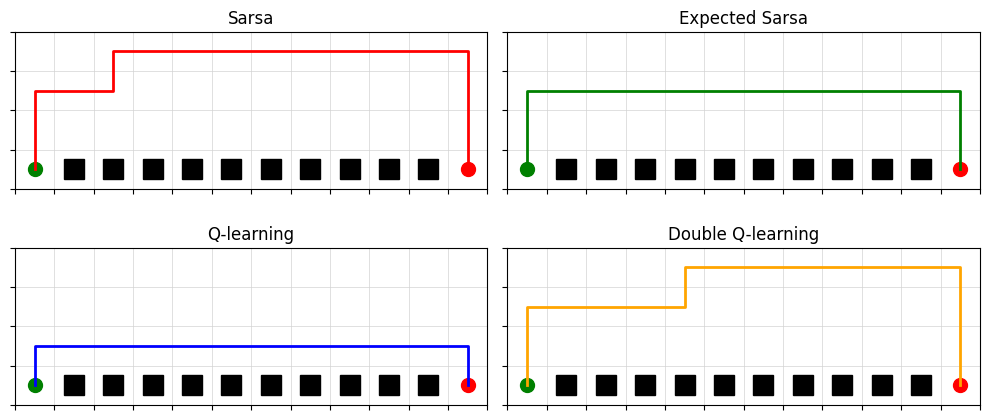

In [38]:
# plot gridworld with learned policy

# plot grid
fig, axs = plt.subplots(2, 2, figsize=(10, 5), tight_layout=True)


plot_method_result(axs[0, 0], sarsa, 'Sarsa', path_sarsa)
plot_method_result(axs[0, 1], e_sarsa, 'Expected Sarsa', path_e_sarsa)
plot_method_result(axs[1, 0], ql, 'Q-learning', path_qlearning)
plot_method_result(axs[1, 1], double_ql, 'Double Q-learning', path_double_qlearning)

# move 0.5 in x and y to center arrows in cells
for ax in axs.flat:
    ax.set_xticks(np.arange(-0.5, env.x_max, 1))
    ax.set_yticks(np.arange(-0.5, env.y_max, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(True, which='both', color='lightgray', linewidth=0.5)
    ax.set_xlim(-0.5, env.x_max - 0.5)
    ax.set_ylim(-0.5, env.y_max - 0.5)
for ax in axs.flat:
    ax.set_aspect('equal')
    # ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
fig.subplots_adjust(right=0.75)
plt.show()

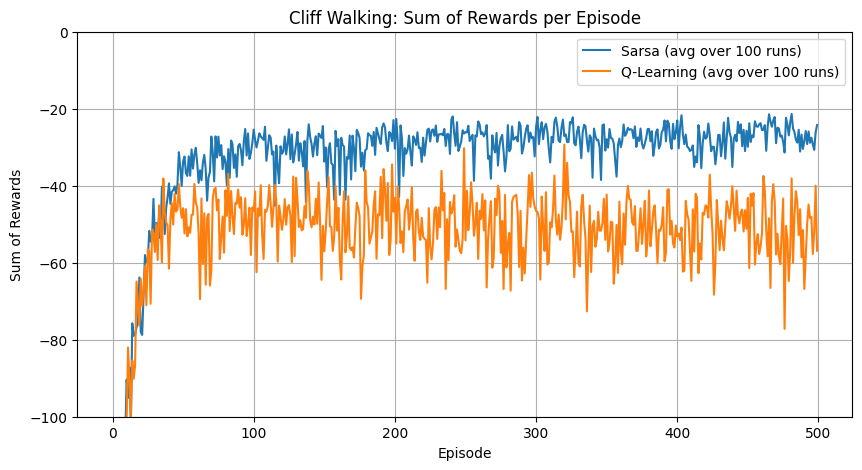

In [40]:
# plot sum rewards per episode
def average_learning_curve(agent_cls, n_runs: int, seed: int = 0):
    curves = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        print(f'Run {run + 1}/{n_runs}', end='\r')
        np.random.seed(seed + run)
        env_run = CliffWalking()
        agent = agent_cls(env_run, alpha=alpha, gamma=1.0, epsilon=epsilon, n_episodes=n_episodes)
        agent.run()
        curves[run] = agent.sum_rewards
    return curves.mean(axis=0)


n_runs = 100  # set to 100 to match the book's averaging
if n_runs == 1:
    sarsa_curve = sarsa.sum_rewards
    ql_curve = ql.sum_rewards
    sarsa_label = 'Sarsa (single run)'
    ql_label = 'Q-Learning (single run)'
    e_sarsa_label = 'Expected Sarsa (single run)'
else:
    sarsa_curve = average_learning_curve(Sarsa, n_runs=n_runs)
    ql_curve = average_learning_curve(QLearning, n_runs=n_runs)
    sarsa_label = f'Sarsa (avg over {n_runs} runs)'
    ql_label = f'Q-Learning (avg over {n_runs} runs)'

plt.figure(figsize=(10, 5))
plt.plot(sarsa_curve, label=sarsa_label)
plt.plot(ql_curve, label=ql_label)
plt.ylim(-100, 0)
plt.xlabel('Episode')
plt.ylabel('Sum of Rewards')
plt.title('Cliff Walking: Sum of Rewards per Episode')
plt.grid()
plt.legend()
plt.show()

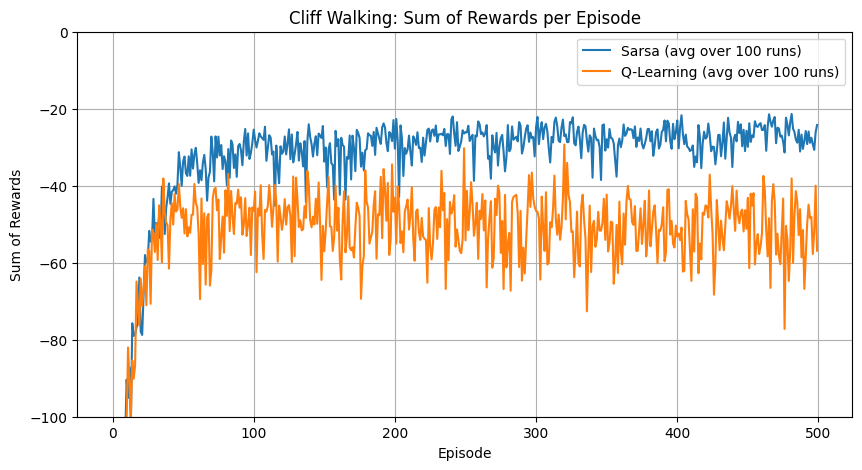
